# TP Final · Car Sales Report
### EDA + Modelado de Regresión + Forecasting de Demanda
Dataset: `missionjee/car-sales-report` (Kaggle) · 23,906 registros · Ene 2022 – Dic 2023

---
## 0. Setup e instalación

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Modelado
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30', '#7F77DD', '#888780']

print('Setup OK')

Setup OK


## 1. Carga del dataset

In [46]:
import pandas as pd
import os

df = None

# =========================================================
# OPCIÓN 1: Kaggle (entorno original)
# =========================================================
try:
    import kagglehub

    path = kagglehub.dataset_download("missionjee/car-sales-report")
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if csv_files:
        df = pd.read_csv(os.path.join(path, csv_files[0]))
        print("Dataset cargado desde KaggleHub")

except Exception as e:
    print("Kaggle no disponible:", e)


# =========================================================
# OPCIÓN 2: Google Drive (Colab)
# =========================================================
if df is None:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        url = "Path al archivo en drive"
        df = pd.read_csv(url)

        print("Dataset cargado desde Google Drive")

    except Exception as e:
        print("Drive no disponible:", e)


# =========================================================
# OPCIÓN 3: Archivo local (descargado manualmente)
# =========================================================
if df is None:
    try:
        path_local = "car_sales.csv"
        df = pd.read_csv(path_local)

        print("Dataset cargado desde archivo local")

    except Exception as e:
        print("No se pudo cargar el dataset:", e)


# =========================================================
# Verificación final
# =========================================================
if df is not None:
    print("\n Shape:", df.shape)
    display(df.head())
else:
    raise Exception("No se pudo cargar el dataset en ninguna de las opciones.")

Using Colab cache for faster access to the 'car-sales-report' dataset.
Dataset cargado desde KaggleHub

 Shape: (23906, 16)


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


## 2. Limpieza y preprocesamiento

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['YearMonth']   = df['Date'].dt.to_period('M')
df['Quarter']     = df['Date'].dt.quarter
df['High_Season'] = df['Month'].isin([9, 11, 12]).astype(int)

df['Engine'] = df['Engine'].str.replace('Â', '', regex=False).str.strip()
print('Engine únicos:', df['Engine'].unique())

df.rename(columns={'Price ($)': 'Price', 'Dealer_No ': 'Dealer_No'}, inplace=True)

DROP_COLS = ['Car_id', 'Customer Name', 'Phone', 'Dealer_No']
df.drop(columns=DROP_COLS, inplace=True, errors='ignore')

df = df[df['Price'] >= 2000].copy()

print('\nNulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Imputar Annual Income == 13500 (valor de relleno)
# Se detectó que el valor 13500 se repite 5273 veces — frecuencia anómala.
# Se sustituye por la mediana del grupo (Company × Body Style).
mask = df['Annual Income'] == 13500
group_med  = df[~mask].groupby(['Company', 'Body Style'])['Annual Income'].median()
global_med = df[~mask]['Annual Income'].median()

def impute_income(row):
    if row['Annual Income'] == 13500:
        return group_med.get((row['Company'], row['Body Style']), global_med)
    return row['Annual Income']

df['Annual Income'] = df.apply(impute_income, axis=1)

# Winsorización al percentil 99 para outliers extremos de ingreso
df['Annual Income'] = df['Annual Income'].clip(upper=df['Annual Income'].quantile(0.99))
df['Log_Income']    = np.log1p(df['Annual Income'])

df['Income_Segment'] = pd.qcut(
    df['Annual Income'], q=4,
    labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
)

print(f'\nShape limpio: {df.shape}')
df.dtypes

Engine únicos: ['Double\xa0Overhead Camshaft' 'Overhead Camshaft']

Nulos por columna:
Series([], dtype: int64)

Shape limpio: (23903, 19)


,0
Date,datetime64[ns]
Gender,object
Annual Income,float64
Dealer_Name,object
Company,object
Model,object
Engine,object
Transmission,object
Color,object
Price,int64


## 3. Análisis univariado

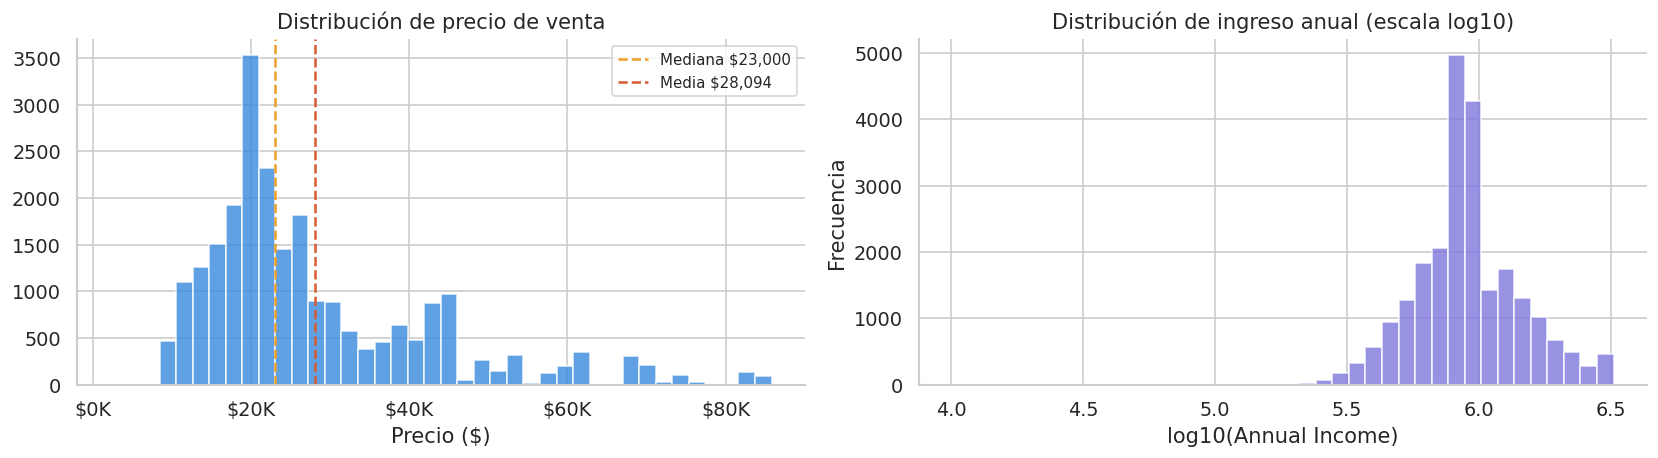

        Price Annual Income
count  23,903        23,903
mean   28,094     1,013,386
std    14,787       527,379
min     2,200        10,080
25%    18,001       700,000
50%    23,000       880,000
75%    34,000     1,176,750
max    85,800     3,229,900


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(df['Price'], bins=40, color=PALETTE[0], alpha=0.8, edgecolor='white')
ax.axvline(df['Price'].median(), color=PALETTE[2], lw=1.5, ls='--', label=f'Mediana ${df["Price"].median():,.0f}')
ax.axvline(df['Price'].mean(),   color=PALETTE[3], lw=1.5, ls='--', label=f'Media ${df["Price"].mean():,.0f}')
ax.set_title('Distribución de precio de venta')
ax.set_xlabel('Precio ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(np.log10(df['Annual Income'] + 1), bins=40, color=PALETTE[4], alpha=0.8, edgecolor='white')
ax.set_title('Distribución de ingreso anual (escala log10)')
ax.set_xlabel('log10(Annual Income)')
ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(df[['Price', 'Annual Income']].describe().applymap(lambda x: f'{x:,.0f}'))

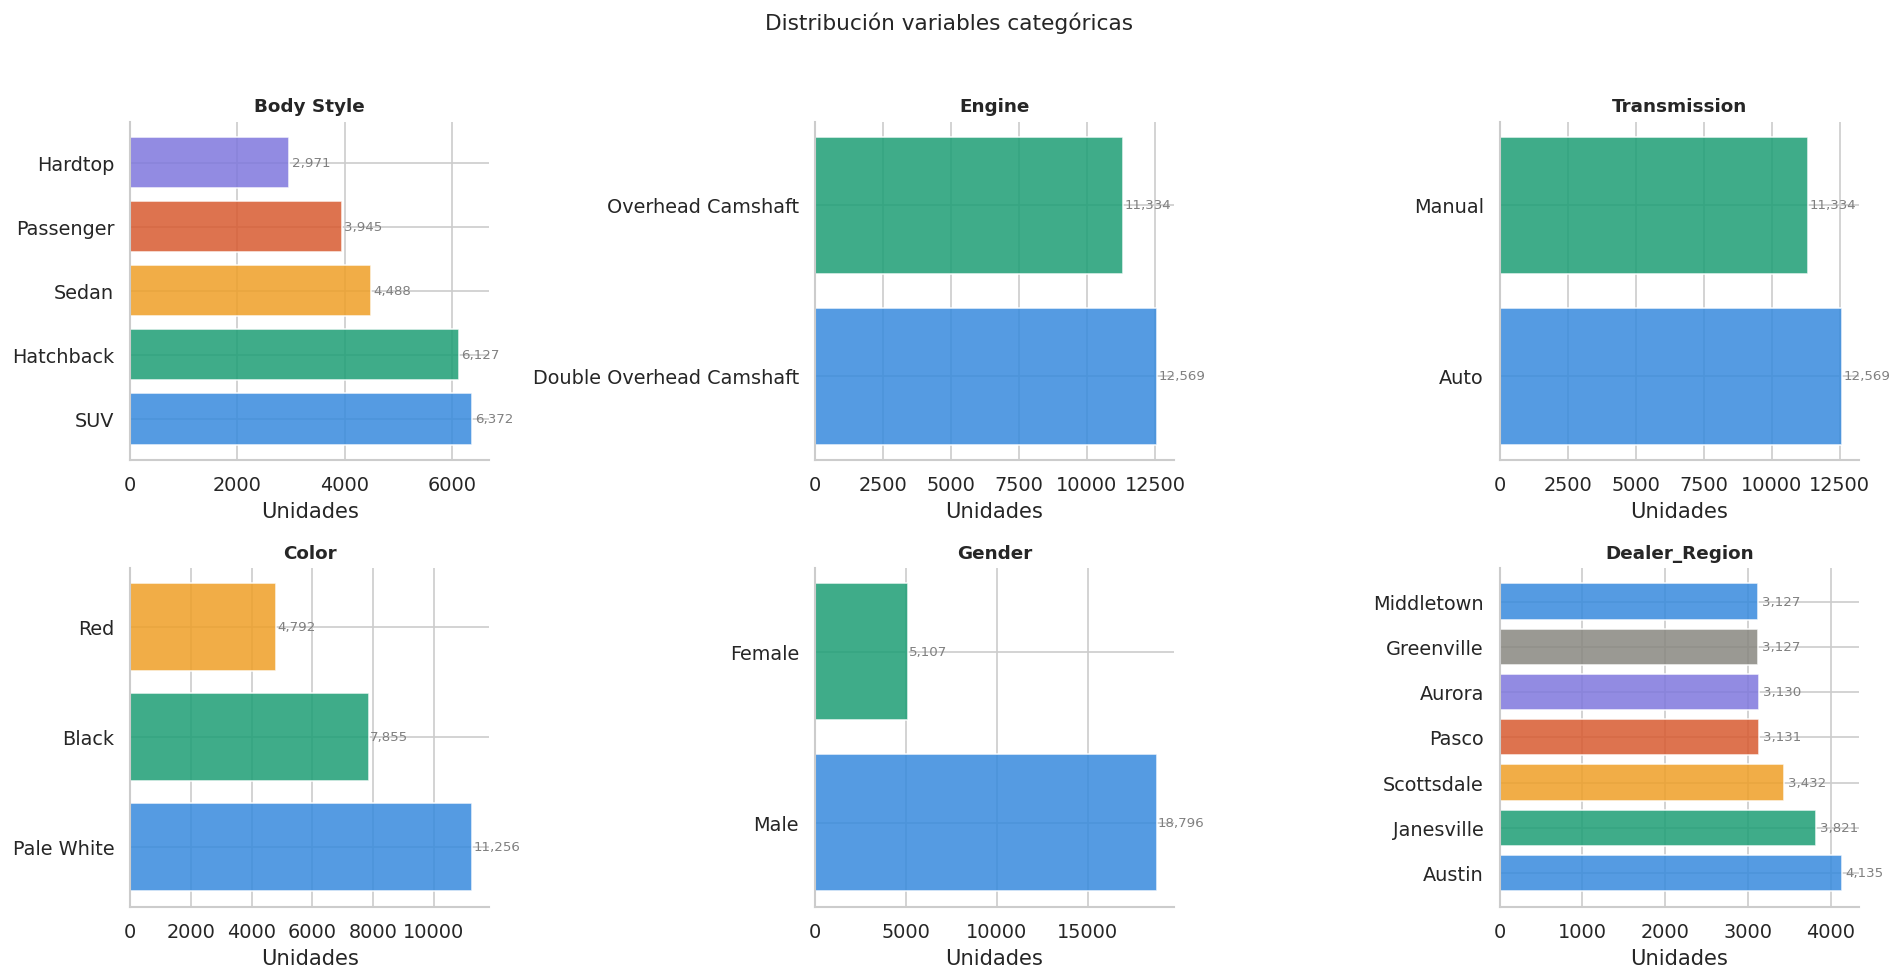

In [ ]:
cat_cols = ['Body Style', 'Engine', 'Transmission', 'Color', 'Gender', 'Dealer_Region']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values, color=PALETTE[:len(counts)], alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Unidades')
    for i, v in enumerate(counts.values):
        ax.text(v + 50, i, f'{v:,}', va='center', fontsize=8, color='gray')

plt.suptitle('Distribución variables categóricas', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Tendencia temporal · Insumo para Forecasting

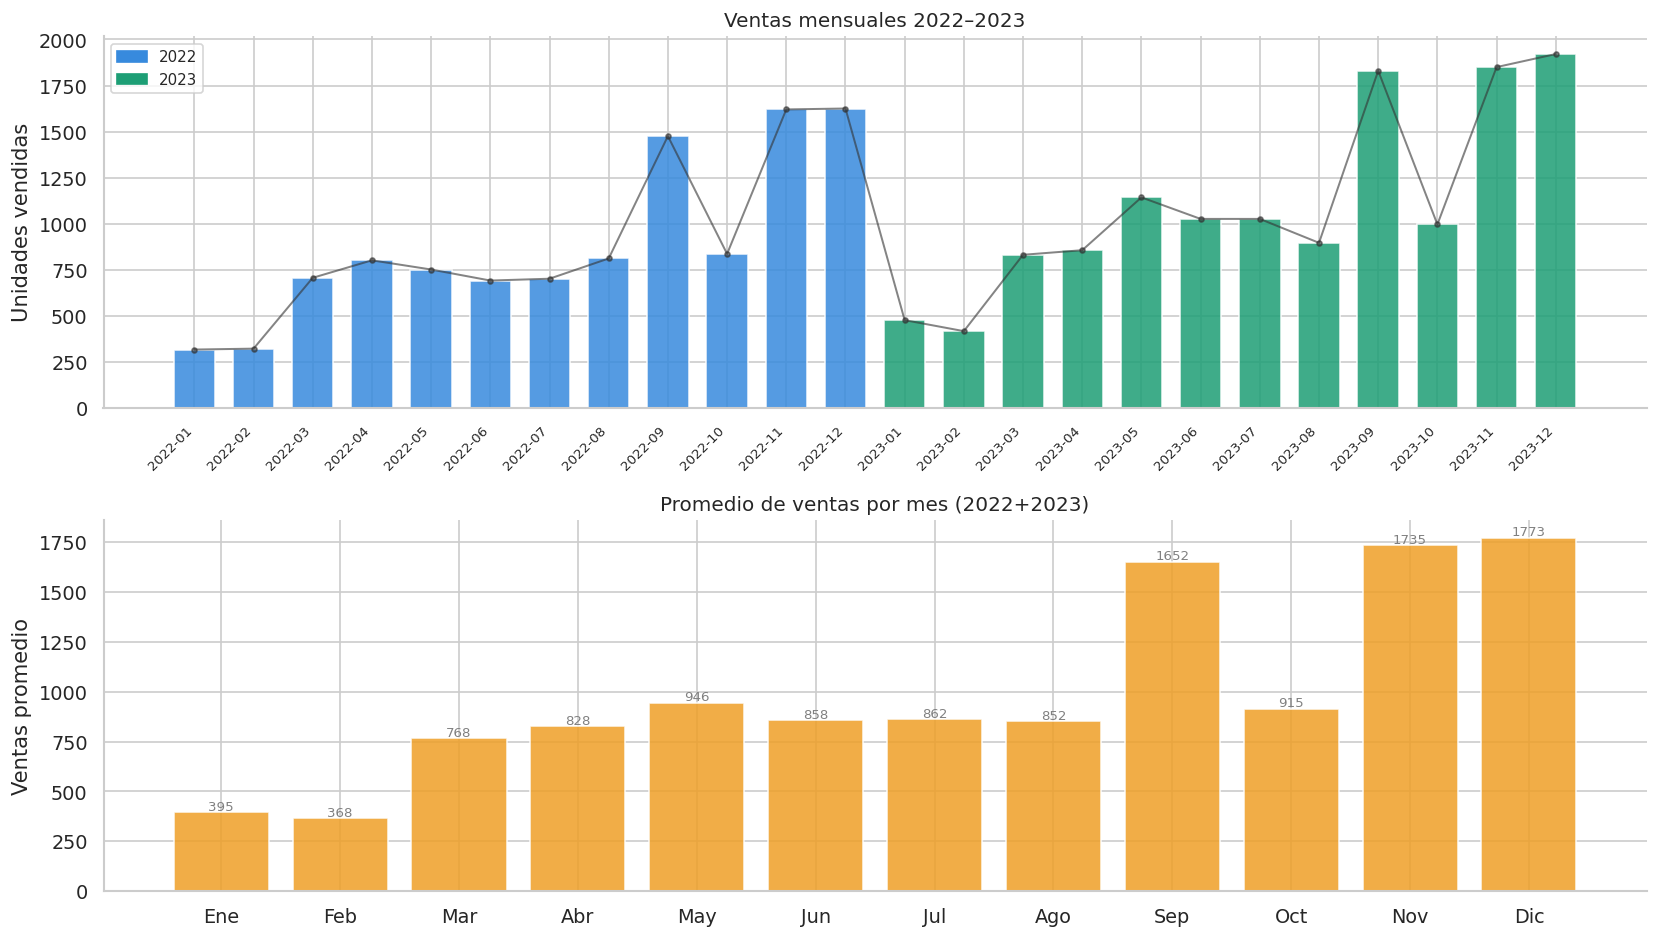

Ventas 2022: 10,645 | Ventas 2023: 13,258 | Crecimiento YoY: 24.5%


In [ ]:
monthly = df.groupby('YearMonth').size().reset_index(name='Sales')
monthly['YM_str'] = monthly['YearMonth'].astype(str)
monthly['Year']   = monthly['YearMonth'].apply(lambda x: x.year)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
colors_bar = [PALETTE[0] if y == 2022 else PALETTE[1] for y in monthly['Year']]
bars = ax.bar(range(len(monthly)), monthly['Sales'], color=colors_bar, alpha=0.85, width=0.7)
ax.plot(range(len(monthly)), monthly['Sales'], color='#333', lw=1.2, marker='o', markersize=3, alpha=0.6)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['YM_str'], rotation=45, ha='right', fontsize=8)
ax.set_title('Ventas mensuales 2022–2023', fontsize=12)
ax.set_ylabel('Unidades vendidas')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PALETTE[0], label='2022'), Patch(color=PALETTE[1], label='2023')], fontsize=9)

ax2 = axes[1]
monthly['Month'] = monthly['YearMonth'].apply(lambda x: x.month)
seasonal = monthly.groupby('Month')['Sales'].mean()
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ax2.bar(month_names, seasonal.values, color=PALETTE[2], alpha=0.85)
ax2.set_title('Promedio de ventas por mes (2022+2023)', fontsize=12)
ax2.set_ylabel('Ventas promedio')
for i, v in enumerate(seasonal.values):
    ax2.text(i, v + 10, f'{v:.0f}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

sales_2022 = monthly[monthly['Year']==2022]['Sales'].sum()
sales_2023 = monthly[monthly['Year']==2023]['Sales'].sum()
print(f'Ventas 2022: {sales_2022:,} | Ventas 2023: {sales_2023:,} | Crecimiento YoY: {(sales_2023/sales_2022-1)*100:.1f}%')

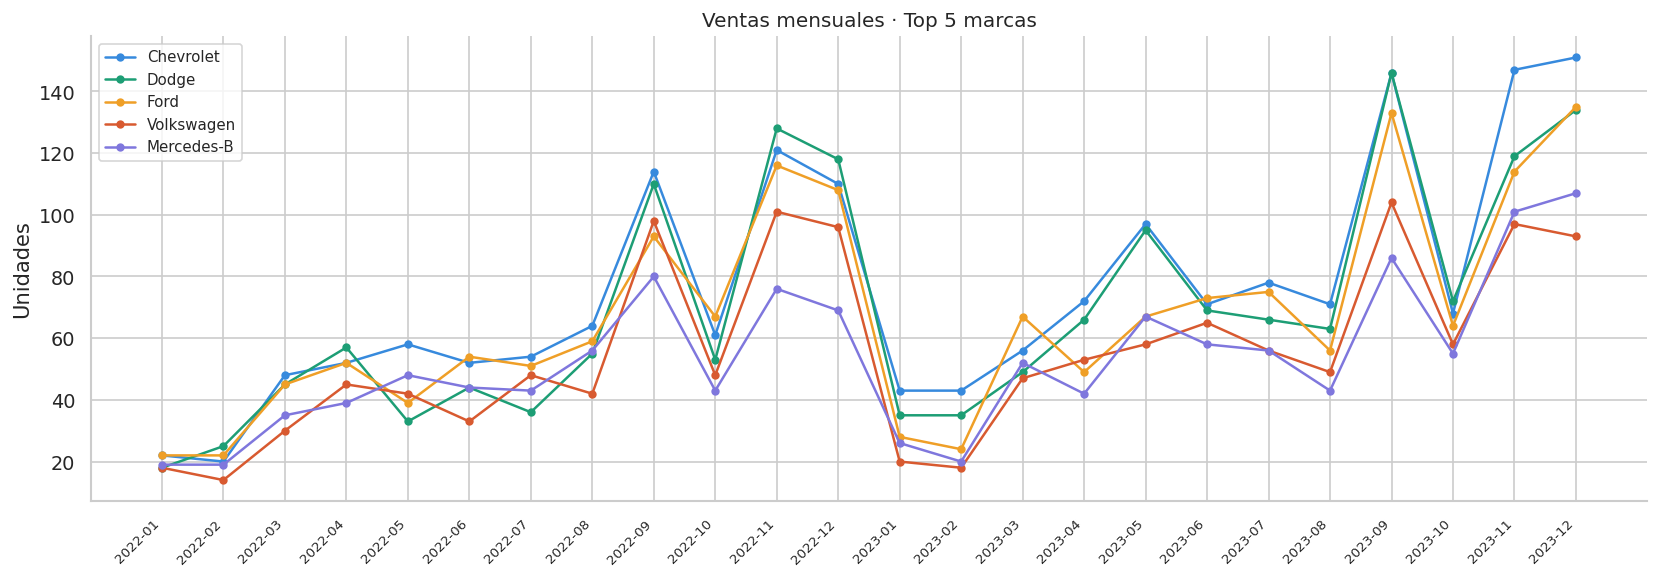

In [ ]:
top5 = df['Company'].value_counts().head(5).index.tolist()
monthly_brand = (
    df[df['Company'].isin(top5)]
    .groupby(['YearMonth', 'Company'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
for i, brand in enumerate(top5):
    ax.plot(monthly_brand.index.astype(str), monthly_brand[brand],
            marker='o', markersize=4, lw=1.5, label=brand, color=PALETTE[i])

ax.set_xticks(range(len(monthly_brand)))
ax.set_xticklabels(monthly_brand.index.astype(str), rotation=45, ha='right', fontsize=8)
ax.set_title('Ventas mensuales · Top 5 marcas', fontsize=12)
ax.set_ylabel('Unidades')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

*Estacionalidad marcada en los meses de Septiembre Octubre y Diciembre (Promociones y beneficio de patentamiento - Negocio)*

## 5. Análisis bivariado · Features para Regresión

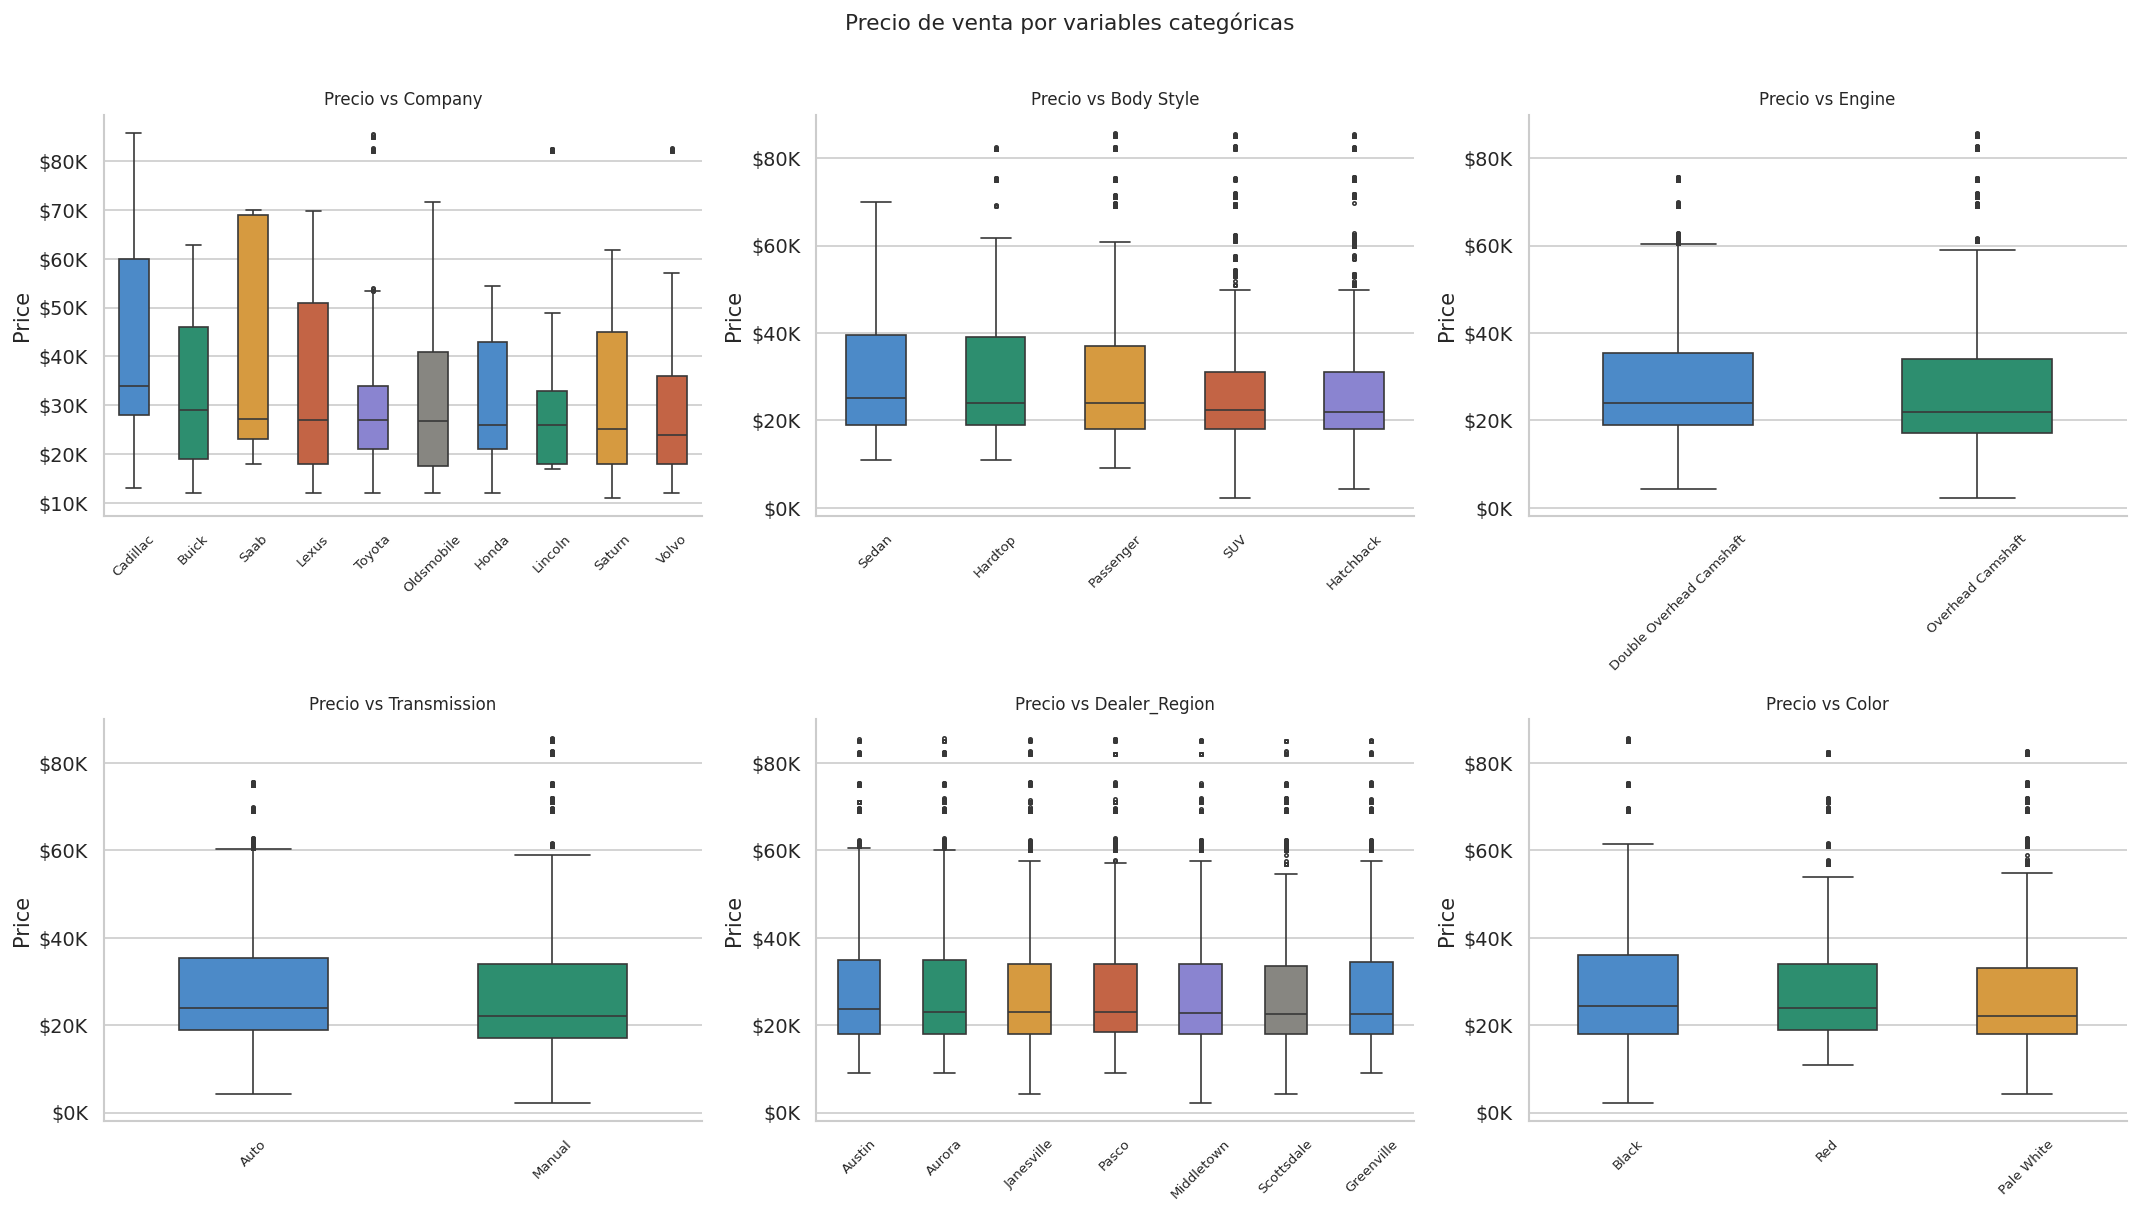

In [ ]:
cat_price = ['Company', 'Body Style', 'Engine', 'Transmission', 'Dealer_Region', 'Color']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, cat_price):
    order = df.groupby(col)['Price'].median().sort_values(ascending=False).index
    if len(order) > 10:
        order = order[:10]
    sub = df[df[col].isin(order)]
    sns.boxplot(data=sub, x=col, y='Price', order=order, ax=ax,
                palette=PALETTE[:len(order)], width=0.5, fliersize=2)
    ax.set_title(f'Precio vs {col}', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Precio de venta por variables categóricas', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

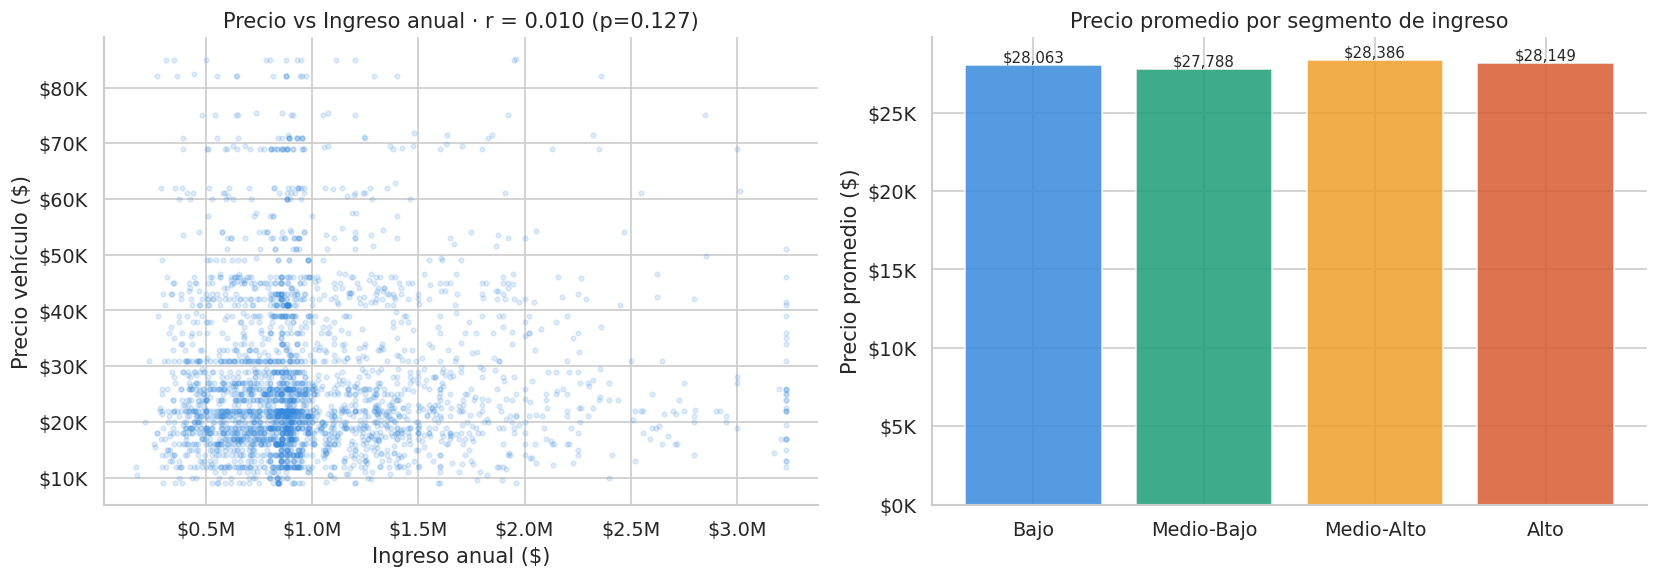

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(min(3000, len(df)), random_state=42)
ax = axes[0]
ax.scatter(sample['Annual Income'], sample['Price'], alpha=0.15, s=8, color=PALETTE[0])
r, p = stats.pearsonr(df['Annual Income'], df['Price'])
ax.set_title(f'Precio vs Ingreso anual · r = {r:.3f} (p={p:.3f})')
ax.set_xlabel('Ingreso anual ($)')
ax.set_ylabel('Precio vehículo ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

ax2 = axes[1]
seg_price = df.groupby('Income_Segment')['Price'].mean()
ax2.bar(seg_price.index, seg_price.values, color=PALETTE[:4], alpha=0.85)
ax2.set_title('Precio promedio por segmento de ingreso')
ax2.set_ylabel('Precio promedio ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(seg_price.values):
    ax2.text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Segmentación de clientes · Marketing

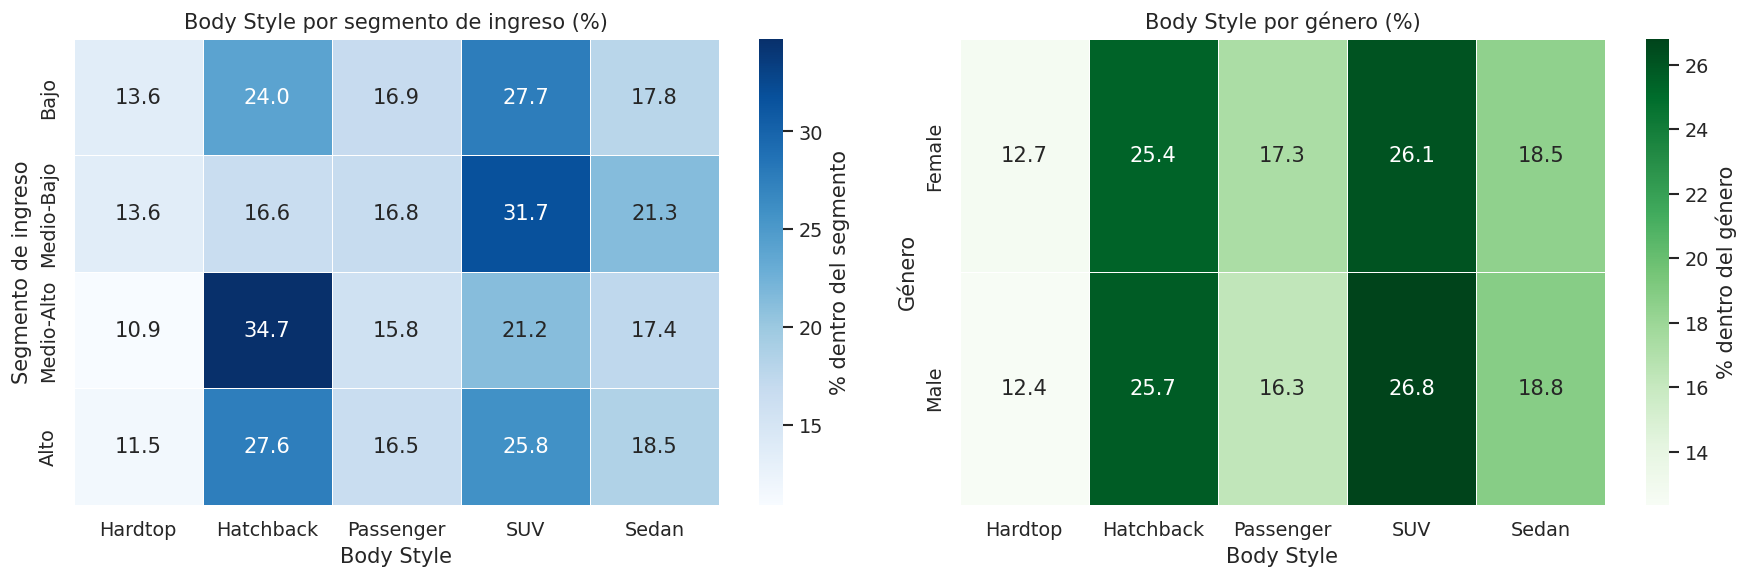


Observación: ambas distribuciones son casi idénticas → segmentar por marca/ingreso, no por género.


In [ ]:
ct = pd.crosstab(df['Income_Segment'], df['Body Style'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '% dentro del segmento'})
axes[0].set_title('Body Style por segmento de ingreso (%)')
axes[0].set_ylabel('Segmento de ingreso')
axes[0].set_xlabel('Body Style')

ct2 = pd.crosstab(df['Gender'], df['Body Style'], normalize='index') * 100
sns.heatmap(ct2, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% dentro del género'})
axes[1].set_title('Body Style por género (%)')
axes[1].set_ylabel('Género')
axes[1].set_xlabel('Body Style')

plt.tight_layout()
plt.show()

print('\nObservación: ambas distribuciones son casi idénticas → segmentar por marca/ingreso, no por género.')

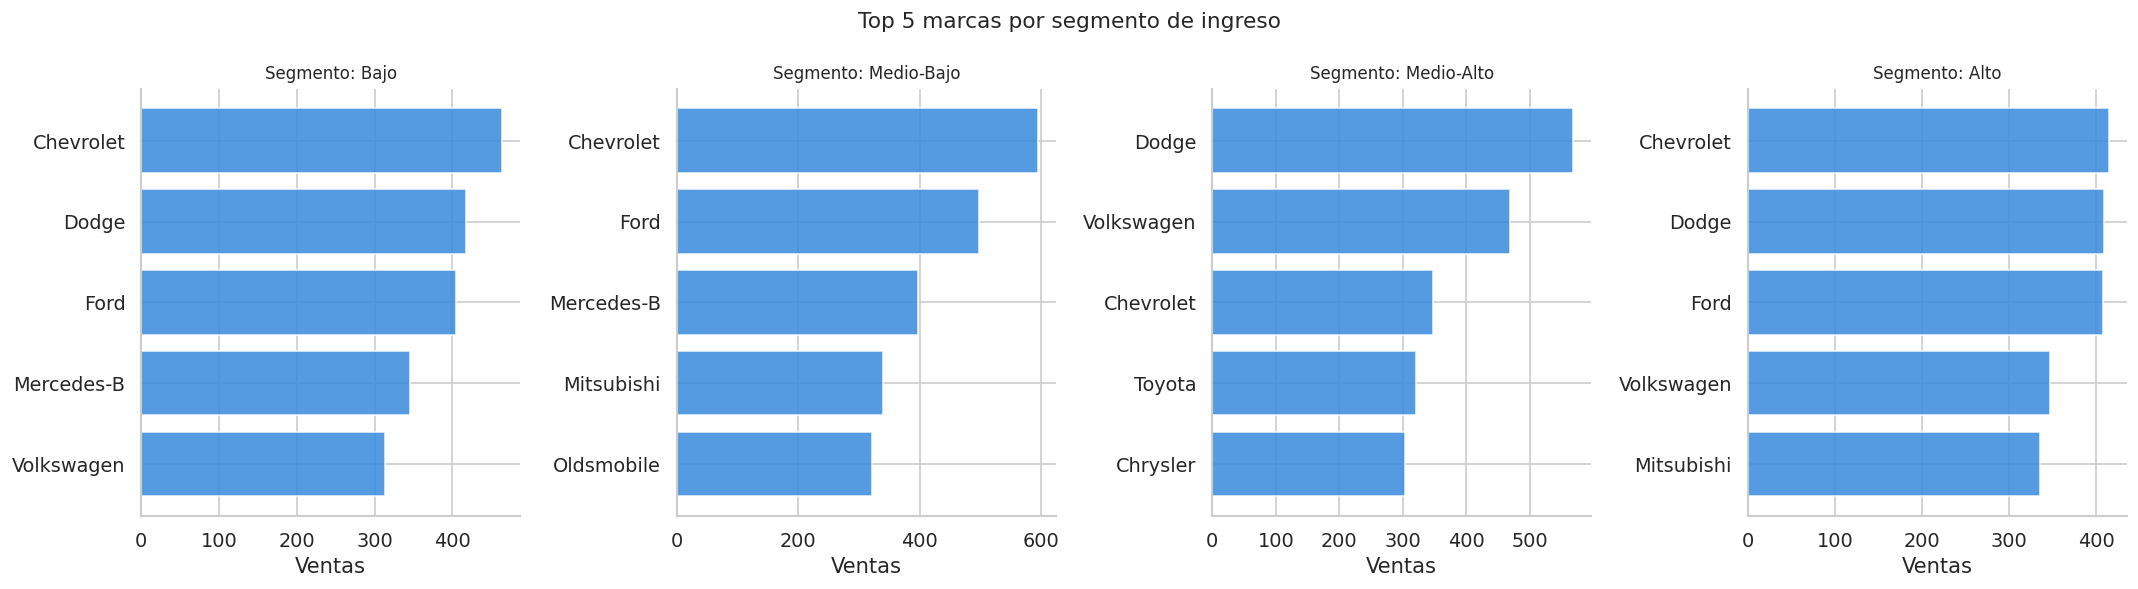

In [ ]:
top_brands_seg = (
    df.groupby(['Income_Segment', 'Company'])
    .size()
    .reset_index(name='count')
    .sort_values(['Income_Segment', 'count'], ascending=[True, False])
    .groupby('Income_Segment')
    .head(5)
)

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
for ax, (seg, grp) in zip(axes, top_brands_seg.groupby('Income_Segment')):
    grp_sorted = grp.sort_values('count', ascending=True)
    ax.barh(grp_sorted['Company'], grp_sorted['count'], color=PALETTE[0], alpha=0.85)
    ax.set_title(f'Segmento: {seg}', fontsize=10)
    ax.set_xlabel('Ventas')

plt.suptitle('Top 5 marcas por segmento de ingreso', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Matriz de correlaciones y análisis de features

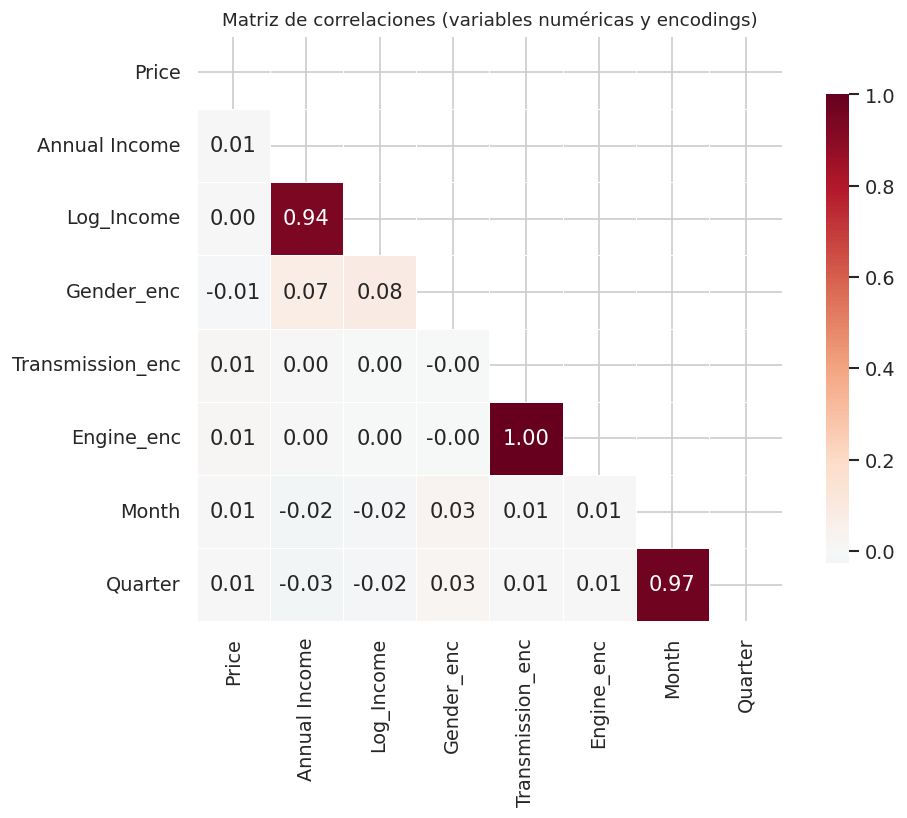

In [40]:
df_enc = df.copy()
df_enc['Gender_enc']       = (df_enc['Gender'] == 'Male').astype(int)
df_enc['Transmission_enc'] = (df_enc['Transmission'] == 'Auto').astype(int)
df_enc['Engine_enc']       = (df_enc['Engine'].str.contains('Double', case=False, na=False)).astype(int)
df_enc['Log_Income']       = np.log1p(df_enc['Annual Income'])

num_cols = ['Price', 'Annual Income', 'Log_Income', 'Gender_enc',
            'Transmission_enc', 'Engine_enc', 'Month', 'Quarter']

corr = df_enc[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlaciones (variables numéricas y encodings)', fontsize=11)
plt.tight_layout()
plt.show()



*Transmission_enc y Engine_enc tienen correlación = 1.0 (son la misma variable). Usar solo una en el modelo.*

In [ ]:
print('=== ANOVA: ¿diferencia significativa de precio por categoría? ===\n')
for col in ['Body Style', 'Engine', 'Transmission', 'Color', 'Gender', 'Dealer_Region']:
    groups = [grp['Price'].values for _, grp in df.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '*** SIGNIFICATIVA' if p_val < 0.001 else ('** sig' if p_val < 0.05 else 'no significativa')
    print(f'  {col:<20} F={f_stat:8.2f}   p={p_val:.4f}   → {sig}')

=== ANOVA: ¿diferencia significativa de precio por categoría? ===

  Body Style           F=   42.00   p=0.0000   → *** SIGNIFICATIVA
  Engine               F=    3.07   p=0.0796   → no significativa
  Transmission         F=    3.07   p=0.0796   → no significativa
  Color                F=   18.31   p=0.0000   → *** SIGNIFICATIVA
  Gender               F=    1.06   p=0.3030   → no significativa
  Dealer_Region        F=    0.72   p=0.6311   → no significativa


## 8. Síntesis del EDA — Decisiones de modelado

### Insights del análisis exploratorio

- Se observan diferencias claras en el precio según variables como `Model`, `Category` o `Body Style`.
- Existen variables categóricas con influencia significativa en la variable objetivo.
- Presencia de outliers en el precio.
- Existencia de relaciones no lineales.


---
## 9. Modelo de Rentabilidad (Regresión sobre `Price`)

**Objetivo:** estimar qué factores explican el precio de venta de un vehículo.  
Este modelo es la base para entender **qué generó la compra** y segmentar estrategias de marketing.

### 9.1 Preparación de features y split

In [ ]:
# Features y target
CAT_COLS = ['Model', 'Body Style', 'Transmission', 'Company', 'Color', 'Gender', 'Dealer_Region']
NUM_COLS = ['Month', 'Quarter', 'High_Season', 'Log_Income']
TARGET   = 'Price'

X = df[CAT_COLS + NUM_COLS]
y = df[TARGET]

# Preprocesador OHE: para Ridge, Random Forest y XGBoost
preprocessor_ohe = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', 'passthrough', NUM_COLS)
])

# Preprocesador Ordinal: para HistGradientBoosting y LightGBM
# Estos modelos manejan categóricas con encoding ordinal de forma nativa
preprocessor_ord = ColumnTransformer([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_COLS),
    ('num', 'passthrough', NUM_COLS)
])

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Train: {X_train.shape[0]:,} muestras')
print(f'Test : {X_test.shape[0]:,} muestras')
print(f'Features categóricas: {CAT_COLS}')
print(f'Features numéricas  : {NUM_COLS}')

Train: 19,122 muestras
Test : 4,781 muestras
Features categóricas: ['Model', 'Body Style', 'Transmission', 'Company', 'Color', 'Gender', 'Dealer_Region']
Features numéricas  : ['Month', 'Quarter', 'High_Season', 'Log_Income']


### 9.2 Función de métricas

In [ ]:
def evaluar(nombre, y_real, y_pred):
    """
    MAE  (Error Absoluto Medio)
         Promedio de cuánto se equivoca el modelo en cada predicción,
         en la misma unidad que el target (dólares).
         → Fácil de interpretar: 'me equivoco $X en promedio'

    RMSE (Raíz del Error Cuadrático Medio)
         Similar al MAE pero penaliza más los errores grandes,
         porque eleva al cuadrado antes de promediar.
         → Siempre >= MAE. Cuanto más se alejan, más errores extremos hay.

    R²   (Coeficiente de Determinación)
         Proporción de la variación del precio que explica el modelo.
         Va de 0 a 1. Un R²=0.58 significa que el modelo explica
         el 58% de la varianza del precio.
         → En datasets de precios de autos sin datos de equipamiento,
           valores entre 0.40–0.65 son razonables.

    MAPE (Error Porcentual Absoluto Medio)
         Error expresado como % del valor real.
         → Útil para comparar entre modelos: 'me equivoco el X% del precio real'
    """
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    print(f'{nombre:<28}  MAE=${mae:>8,.0f}  RMSE=${rmse:>8,.0f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}

resultados = []

### 9.3 Regresión Lineal — baseline

In [ ]:
pipe_ridge = Pipeline([
    ('pre', preprocessor_ohe),
    ('mdl', Ridge(alpha=10))
])
pipe_ridge.fit(X_train, y_train)
y_pred_ridge = pipe_ridge.predict(X_test)

resultados.append(evaluar('Regresión Lineal', y_test, y_pred_ridge))


Regresión Lineal              MAE=$   9,582  RMSE=$  12,859  R²=0.2224  MAPE=39.63%

Interpretación: R² bajo indica que las relaciones entre features y precio
  no son lineales. Se esperan mejoras significativas con modelos basados en árboles.


### 9.4 Random Forest

In [ ]:
pipe_rf = Pipeline([
    ('pre', preprocessor_ohe),
    ('mdl', RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

resultados.append(evaluar('Random Forest', y_test, y_pred_rf))
print('\nRandom Forest mejora sobre Ridge pero queda por debajo de los modelos de boosting.')

Random Forest                 MAE=$   9,601  RMSE=$  12,996  R²=0.2058  MAPE=40.62%

Random Forest mejora sobre Ridge pero queda por debajo de los modelos de boosting.


### 9.5 XGBoost

In [ ]:
pipe_xgb = Pipeline([
    ('pre', preprocessor_ohe),
    ('mdl', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ))
])
pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)

resultados.append(evaluar('XGBoost', y_test, y_pred_xgb))
print('\nXGBoost mejora significativamente sobre Random Forest gracias al boosting secuencial.')

XGBoost                       MAE=$   7,505  RMSE=$  10,304  R²=0.5007  MAPE=31.45%

XGBoost mejora significativamente sobre Random Forest gracias al boosting secuencial.


### 9.6 HistGradientBoosting

In [ ]:
pipe_hgb = Pipeline([
    ('pre', preprocessor_ord),
    ('mdl', HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])
pipe_hgb.fit(X_train, y_train)
y_pred_hgb = pipe_hgb.predict(X_test)

resultados.append(evaluar('HistGradientBoosting', y_test, y_pred_hgb))
print('\nHistGB supera a XGBoost gracias al enfoque de crecimiento leaf-wise con histogramas.')

HistGradientBoosting          MAE=$   6,650  RMSE=$   9,548  R²=0.5713  MAPE=27.89%

HistGB supera a XGBoost gracias al enfoque de crecimiento leaf-wise con histogramas.


### 9.7 LightGBM

In [ ]:
pipe_lgbm = Pipeline([
    ('pre', preprocessor_ord),
    ('mdl', LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ))
])
pipe_lgbm.fit(X_train, y_train)
y_pred_lgbm = pipe_lgbm.predict(X_test)

resultados.append(evaluar('LightGBM', y_test, y_pred_lgbm))

LightGBM                      MAE=$   6,688  RMSE=$   9,547  R²=0.5714  MAPE=28.09%


### 9.8 Tabla comparativa de métricas

In [ ]:
df_res = pd.DataFrame(resultados).set_index('Modelo')

# Resaltar mejor valor en cada métrica
display(
    df_res.style
    .format({'MAE': '${:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}', 'MAPE': '{:.2f}%'})
    .highlight_min(subset=['MAE', 'RMSE', 'MAPE'], color='#d4edda')
    .highlight_max(subset=['R²'], color='#d4edda')
)

mejor = df_res['R²'].idxmax()
print(f'\n→ Mejor modelo: {mejor}')

,MAE,RMSE,R²,MAPE
Modelo,,,,
Regresión Lineal,"$9,582","$12,859",0.2224,39.63%
Random Forest,"$9,601","$12,996",0.2058,40.62%
XGBoost,"$7,505","$10,304",0.5007,31.45%
HistGradientBoosting,"$6,650","$9,548",0.5713,27.89%
LightGBM,"$6,688","$9,547",0.5714,28.09%



→ Mejor modelo: LightGBM


### 9.9 Cross-validation y análisis de overfitting

In [ ]:
# Validamos que la mejora de LightGBM no sea suerte del split 80/20
# usando cross-validation de 5 folds y comparando R² train vs test

cv = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = [
    ('XGBoost',             pipe_xgb),
    ('HistGradientBoosting', pipe_hgb),
    ('LightGBM',            pipe_lgbm),
]

print('=== Cross-validation 5-fold (R²) ===')
for nombre, pipe in modelos_cv:
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2', n_jobs=-1)
    r2_tr  = r2_score(y_train, pipe.predict(X_train))
    r2_te  = r2_score(y_test,  pipe.predict(X_test))
    print(f'  {nombre:<25}  CV={scores.mean():.4f} ± {scores.std():.4f}  '
          f'train={r2_tr:.4f}  test={r2_te:.4f}  gap={r2_tr-r2_te:.4f}')


=== Cross-validation 5-fold (R²) ===
  XGBoost                    CV=0.5133 ± 0.0124  train=0.5857  test=0.5007  gap=0.0850
  HistGradientBoosting       CV=0.5844 ± 0.0129  train=0.6241  test=0.5713  gap=0.0528
  LightGBM                   CV=0.5776 ± 0.0100  train=0.6233  test=0.5714  gap=0.0520


## Conclusion de Modelos

- LightGBM presenta el menor RMSE, lo que indica mejor precisión global.
- XGBoost obtiene resultados similares, aunque con ligeras diferencias en error.
- Ambos modelos arrojas mejores resultados que la regresion lineal, con diferencia.

La consistencia entre métricas refuerza la elección de modelos basados en árboles como mejor alternativa para este problema.

### 9.10 Visualización: predichos vs reales — LightGBM (mejor modelo)

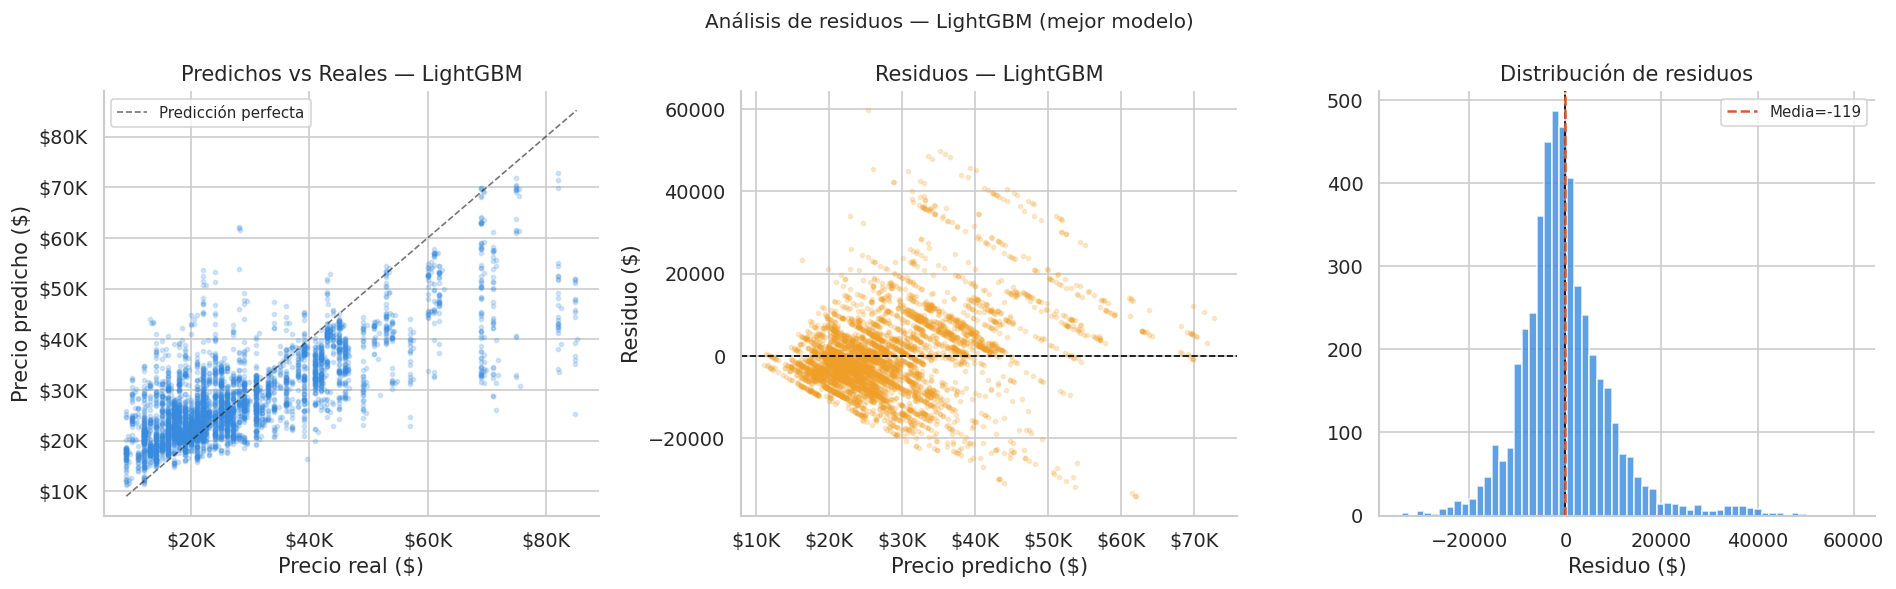

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predichos vs Reales
ax = axes[0]
ax.scatter(y_test, y_pred_lgbm, alpha=0.2, s=6, color=PALETTE[0])
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.6, label='Predicción perfecta')
ax.set_xlabel('Precio real ($)')
ax.set_ylabel('Precio predicho ($)')
ax.set_title('Predichos vs Reales — LightGBM')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9)

# Residuos
ax = axes[1]
residuos = y_test.values - y_pred_lgbm
ax.scatter(y_pred_lgbm, residuos, alpha=0.2, s=6, color=PALETTE[2])
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Precio predicho ($)')
ax.set_ylabel('Residuo ($)')
ax.set_title('Residuos — LightGBM')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Distribución de residuos
ax = axes[2]
ax.hist(residuos, bins=60, color=PALETTE[0], alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', lw=1, ls='--')
ax.axvline(residuos.mean(), color=PALETTE[3], lw=1.5, ls='--',
           label=f'Media={residuos.mean():,.0f}')
ax.set_xlabel('Residuo ($)')
ax.set_title('Distribución de residuos')
ax.legend(fontsize=9)

plt.suptitle('Análisis de residuos — LightGBM (mejor modelo)', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis de errores


*   El modelo presenta mayor error en valores extremos de precio y mejores resultados en el rango de 15.000 - 40.000 lo que nos dice que el modelo es más confiable en segmentos intermedios.
*   Se observa una tendencia a subestimar vehículos de alto valor.



### 9.11 Feature Importance — LightGBM

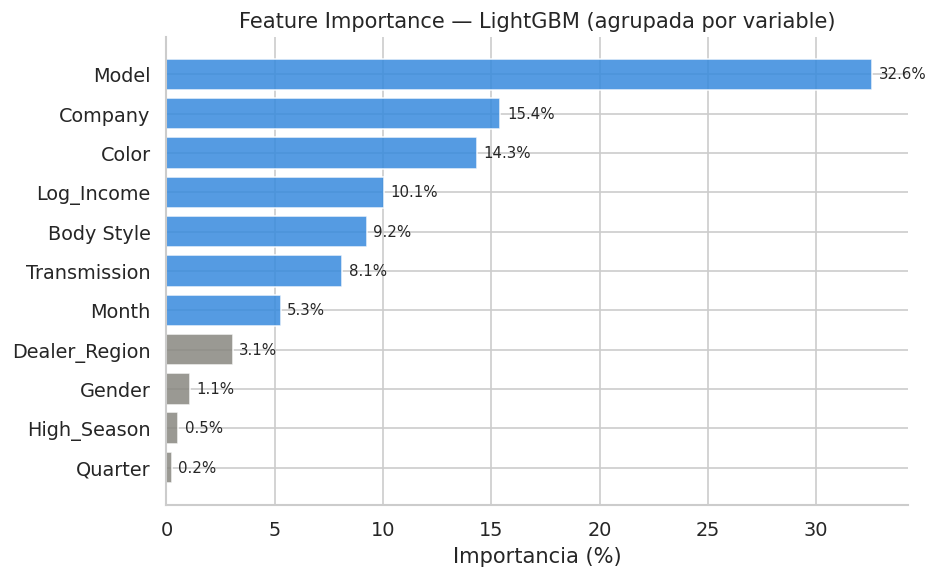


Importancia agrupada:
Model            32.60%
Company          15.42%
Color            14.32%
Log_Income       10.06%
Body Style        9.25%
Transmission      8.13%
Month             5.28%
Dealer_Region     3.06%
Gender            1.10%
High_Season       0.54%
Quarter           0.24%


In [ ]:
fi_series = pd.Series(importancias, index=feat_names)
fi_group  = fi_series.groupby(nombre_original).sum()

# 👇 NORMALIZAR
fi_group = fi_group / fi_group.sum()

fi_group = fi_group.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors_fi = [PALETTE[0] if v > 0.05 else PALETTE[5] for v in fi_group.values]
bars = plt.barh(fi_group.index, fi_group.values * 100, color=colors_fi, alpha=0.85)

plt.xlabel('Importancia (%)')
plt.title('Feature Importance — LightGBM (agrupada por variable)')

for bar, val in zip(bars, fi_group.values):
    plt.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nImportancia agrupada:')
print(fi_group.sort_values(ascending=False).map('{:.2%}'.format).to_string())

### Interpretabilidad del modelo

- Las variables más importantes para la predicción son: `Model`, `Company`, `Color`.
- La importancia se concentra en un conjunto reducido de variables.


### 9.12 Interpretación de negocio

In [ ]:
df['Income_Segment'] = pd.qcut(
    df['Annual Income'], q=4,
    labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
)

seg_summary = df.groupby('Income_Segment').agg(
    Clientes    = ('Price', 'count'),
    Precio_Medio= ('Price', 'mean'),
    Income_Medio= ('Annual Income', 'mean'),
    Body_Top    = ('Body Style', lambda x: x.value_counts().index[0]),
    Model_Top   = ('Model', lambda x: x.value_counts().index[0]),
    Marca_Top   = ('Company', lambda x: x.value_counts().index[0])
).round(0)

print('=== Perfil de segmentos de cliente ===')
display(seg_summary)

print()
print('ESTRATEGIAS DE MARKETING SUGERIDAS:')
print('  Segmento ALTO      → marcas premium (Cadillac, Lexus, Saab), ticket >$35K')
print('  Segmento MEDIO-ALTO→ BMW, Mercedes, Buick, body style Sedan/Hardtop')
print('  Segmento MEDIO-BAJO→ Toyota, Ford, Volkswagen, SUV y Hatchback')
print('  Segmento BAJO      → Chevrolet, Dodge, Mitsubishi, Hatchback')

=== Perfil de segmentos de cliente ===


,Clientes,Precio_Medio,Income_Medio,Body_Top,Model_Top,Marca_Top
Income_Segment,,,,,,
Bajo,6012,28063.0,535298.0,SUV,Ram Pickup,Chevrolet
Medio-Bajo,6081,27788.0,814000.0,SUV,Silhouette,Chevrolet
Medio-Alto,5834,28386.0,971573.0,Hatchback,Passat,Dodge
Alto,5976,28149.0,1738064.0,Hatchback,Diamante,Chevrolet



ESTRATEGIAS DE MARKETING SUGERIDAS:
  Segmento ALTO      → marcas premium (Cadillac, Lexus, Saab), ticket >$35K
  Segmento MEDIO-ALTO→ BMW, Mercedes, Buick, body style Sedan/Hardtop
  Segmento MEDIO-BAJO→ Toyota, Ford, Volkswagen, SUV y Hatchback
  Segmento BAJO      → Chevrolet, Dodge, Mitsubishi, Hatchback


---
## 10. Forecasting de Demanda Mensual

**Objetivo:** proyectar la demanda mensual de vehículos por marca.  
**Validación:** división temporal — entrenamos con los primeros períodos y evaluamos en los últimos 4 meses.

### 10.1 Preparación de la serie temporal

In [ ]:
monthly_total = (
    df.groupby('YearMonth')
    .size()
    .reset_index(name='Sales')
)
monthly_total['ds'] = monthly_total['YearMonth'].dt.to_timestamp()
ts = monthly_total.set_index('ds').asfreq('MS')['Sales']

N_TEST   = 4
ts_train = ts.iloc[:-N_TEST]
ts_test  = ts.iloc[-N_TEST:]

print(f'Serie total: {len(ts)} meses ({ts.index[0].strftime("%b %Y")} → {ts.index[-1].strftime("%b %Y")})')
print(f'Train: {len(ts_train)} meses ({ts_train.index[0].strftime("%b %Y")} → {ts_train.index[-1].strftime("%b %Y")})')
print(f'Test : {len(ts_test)} meses ({ts_test.index[0].strftime("%b %Y")} → {ts_test.index[-1].strftime("%b %Y")})')

print('\nValores test (reales):')
for d, v in ts_test.items():
    print(f'  {d.strftime("%b %Y")}: {v:,}')

Serie total: 24 meses (Jan 2022 → Dec 2023)
Train: 20 meses (Jan 2022 → Aug 2023)
Test : 4 meses (Sep 2023 → Dec 2023)

Valores test (reales):
  Sep 2023: 1,830
  Oct 2023: 995
  Nov 2023: 1,850
  Dec 2023: 1,921


### 10.2 Análisis de la serie: estacionariedad y autocorrelación

=== Test Dickey-Fuller Aumentado ===
  Estadístico ADF : -2.7355
  p-valor         : 0.0681
  Valores críticos: {'1%': np.float64(-3.7529275211638033), '5%': np.float64(-2.998499866852963), '10%': np.float64(-2.6389669754253307)}
  → Serie NO estacionaria. Se aplicará diferenciación (d=1).


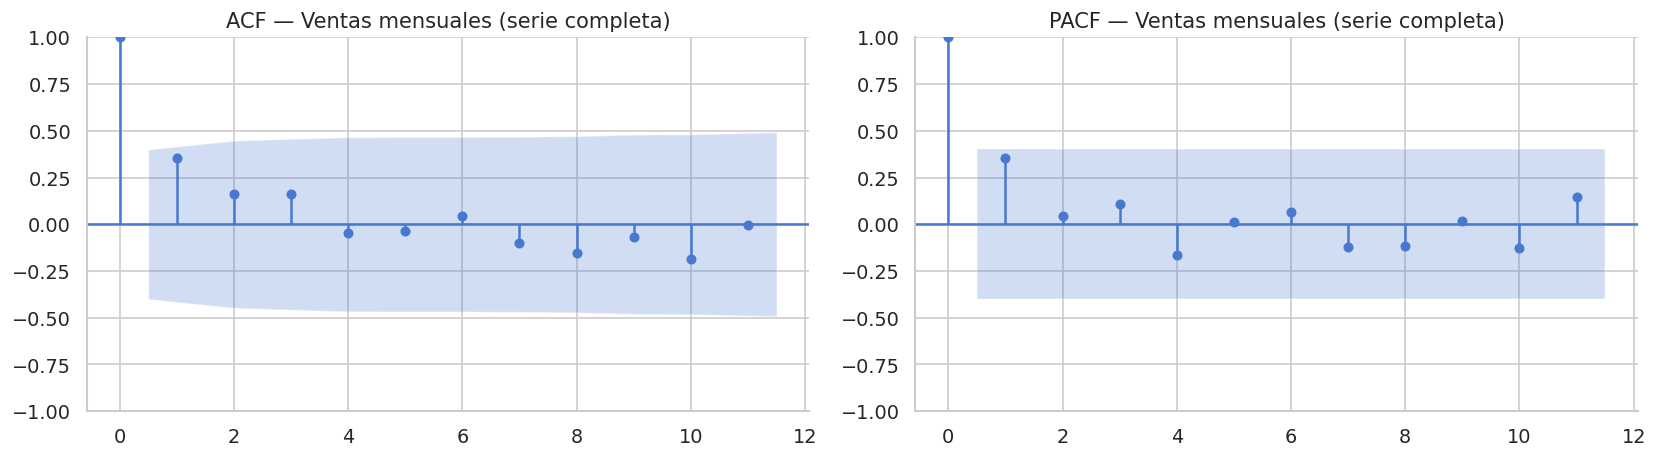

Lags graficados: 11 (sobre 24 observaciones totales)
Interpretación: picos en rezagos altos confirman estacionalidad anual.


In [ ]:
adf_result = adfuller(ts.values, autolag='AIC')
print('=== Test Dickey-Fuller Aumentado ===')
print(f'  Estadístico ADF : {adf_result[0]:.4f}')
print(f'  p-valor         : {adf_result[1]:.4f}')
print(f'  Valores críticos: {adf_result[4]}')
if adf_result[1] < 0.05:
    print('  → Serie ESTACIONARIA (p < 0.05). d=0 es posible.')
else:
    print('  → Serie NO estacionaria. Se aplicará diferenciación (d=1).')

max_lags = len(ts) // 2 - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( ts.values, ax=axes[0], lags=max_lags, title='ACF — Ventas mensuales (serie completa)')
plot_pacf(ts.values, ax=axes[1], lags=max_lags, title='PACF — Ventas mensuales (serie completa)')
plt.tight_layout()
plt.show()
print(f'Lags graficados: {max_lags} (sobre {len(ts)} observaciones totales)')
print('Interpretación: picos en rezagos altos confirman estacionalidad anual.')

### 10.3 Modelo SARIMA

In [ ]:
# p,d,q = componentes AR, diferenciación, MA
# P,D,Q,s = componentes estacionales; s=12 (mensual con ciclo anual)

sarima_model = SARIMAX(
    ts_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   20
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Sun, 29 Mar 2026   AIC                             10.000
Time:                                    14:38:18   BIC                                nan
Sample:                                01-01-2022   HQIC                               nan
                                     - 08-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2517         -0        inf      0.000      -1.252      -1.252
ma.L1          1.0543         -0   

In [ ]:
pred_sarima = sarima_fit.forecast(steps=N_TEST)
pred_sarima.index = ts_test.index

mae_s  = mean_absolute_error(ts_test, pred_sarima)
rmse_s = np.sqrt(mean_squared_error(ts_test, pred_sarima))
mape_s = np.mean(np.abs((ts_test.values - pred_sarima.values) / ts_test.values)) * 100

print('=== SARIMA — Métricas de test ===')
print(f'  MAE  = {mae_s:,.1f} unidades')
print(f'  RMSE = {rmse_s:,.1f} unidades')
print(f'  MAPE = {mape_s:.1f}%')

print('\nComparación predicho vs real:')
comp_sarima = pd.DataFrame({'Real': ts_test.values, 'SARIMA': pred_sarima.values.round(0)},
                            index=ts_test.index.strftime('%b %Y'))
comp_sarima['Error']  = (comp_sarima['Real'] - comp_sarima['SARIMA']).round(0)
comp_sarima['Error%'] = ((comp_sarima['Error'] / comp_sarima['Real']) * 100).round(1).astype(str) + '%'
display(comp_sarima)


=== SARIMA — Métricas de test ===
  MAE  = 175.3 unidades
  RMSE = 213.1 unidades
  MAPE = 10.9%

Comparación predicho vs real:


,Real,SARIMA,Error,Error%
ds,,,,
Sep 2023,1830,1799.0,31.0,1.7%
Oct 2023,995,860.0,135.0,13.6%
Nov 2023,1850,2020.0,-170.0,-9.2%
Dec 2023,1921,1555.0,366.0,19.1%


### 10.4 Modelo XGBoost con variables temporales

In [ ]:
ts_df = ts.reset_index().rename(columns={'ds': 'date', 'Sales': 'y'})
ts_df['month']       = ts_df['date'].dt.month
ts_df['year']        = ts_df['date'].dt.year
ts_df['quarter']     = ts_df['date'].dt.quarter
ts_df['high_season'] = ts_df['month'].isin([9, 11, 12]).astype(int)
ts_df['lag_1']       = ts_df['y'].shift(1)
ts_df['lag_3']       = ts_df['y'].shift(3)
ts_df['lag_12']      = ts_df['y'].shift(12)
ts_df['roll3']       = ts_df['y'].shift(1).rolling(3).mean()
ts_df = ts_df.dropna().reset_index(drop=True)

FEAT_TS = ['month', 'year', 'quarter', 'high_season', 'lag_1', 'lag_3', 'lag_12', 'roll3']

X_ts    = ts_df[FEAT_TS]
y_ts    = ts_df['y']
X_ts_tr = X_ts.iloc[:-N_TEST]
X_ts_te = X_ts.iloc[-N_TEST:]
y_ts_tr = y_ts.iloc[:-N_TEST]
y_ts_te = y_ts.iloc[-N_TEST:]

xgb_ts = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.9, random_state=42, verbosity=0
)
xgb_ts.fit(X_ts_tr, y_ts_tr)
pred_xgb_ts = xgb_ts.predict(X_ts_te)

mae_x  = mean_absolute_error(y_ts_te, pred_xgb_ts)
rmse_x = np.sqrt(mean_squared_error(y_ts_te, pred_xgb_ts))
mape_x = np.mean(np.abs((y_ts_te.values - pred_xgb_ts) / y_ts_te.values)) * 100

print('=== XGBoost-TS — Métricas de test ===')
print(f'  MAE  = {mae_x:,.1f} unidades')
print(f'  RMSE = {rmse_x:,.1f} unidades')
print(f'  MAPE = {mape_x:.1f}%')



=== XGBoost-TS — Métricas de test ===
  MAE  = 753.8 unidades
  RMSE = 843.7 unidades
  MAPE = 41.5%


### 10.5 Visualización comparativa — Forecasting

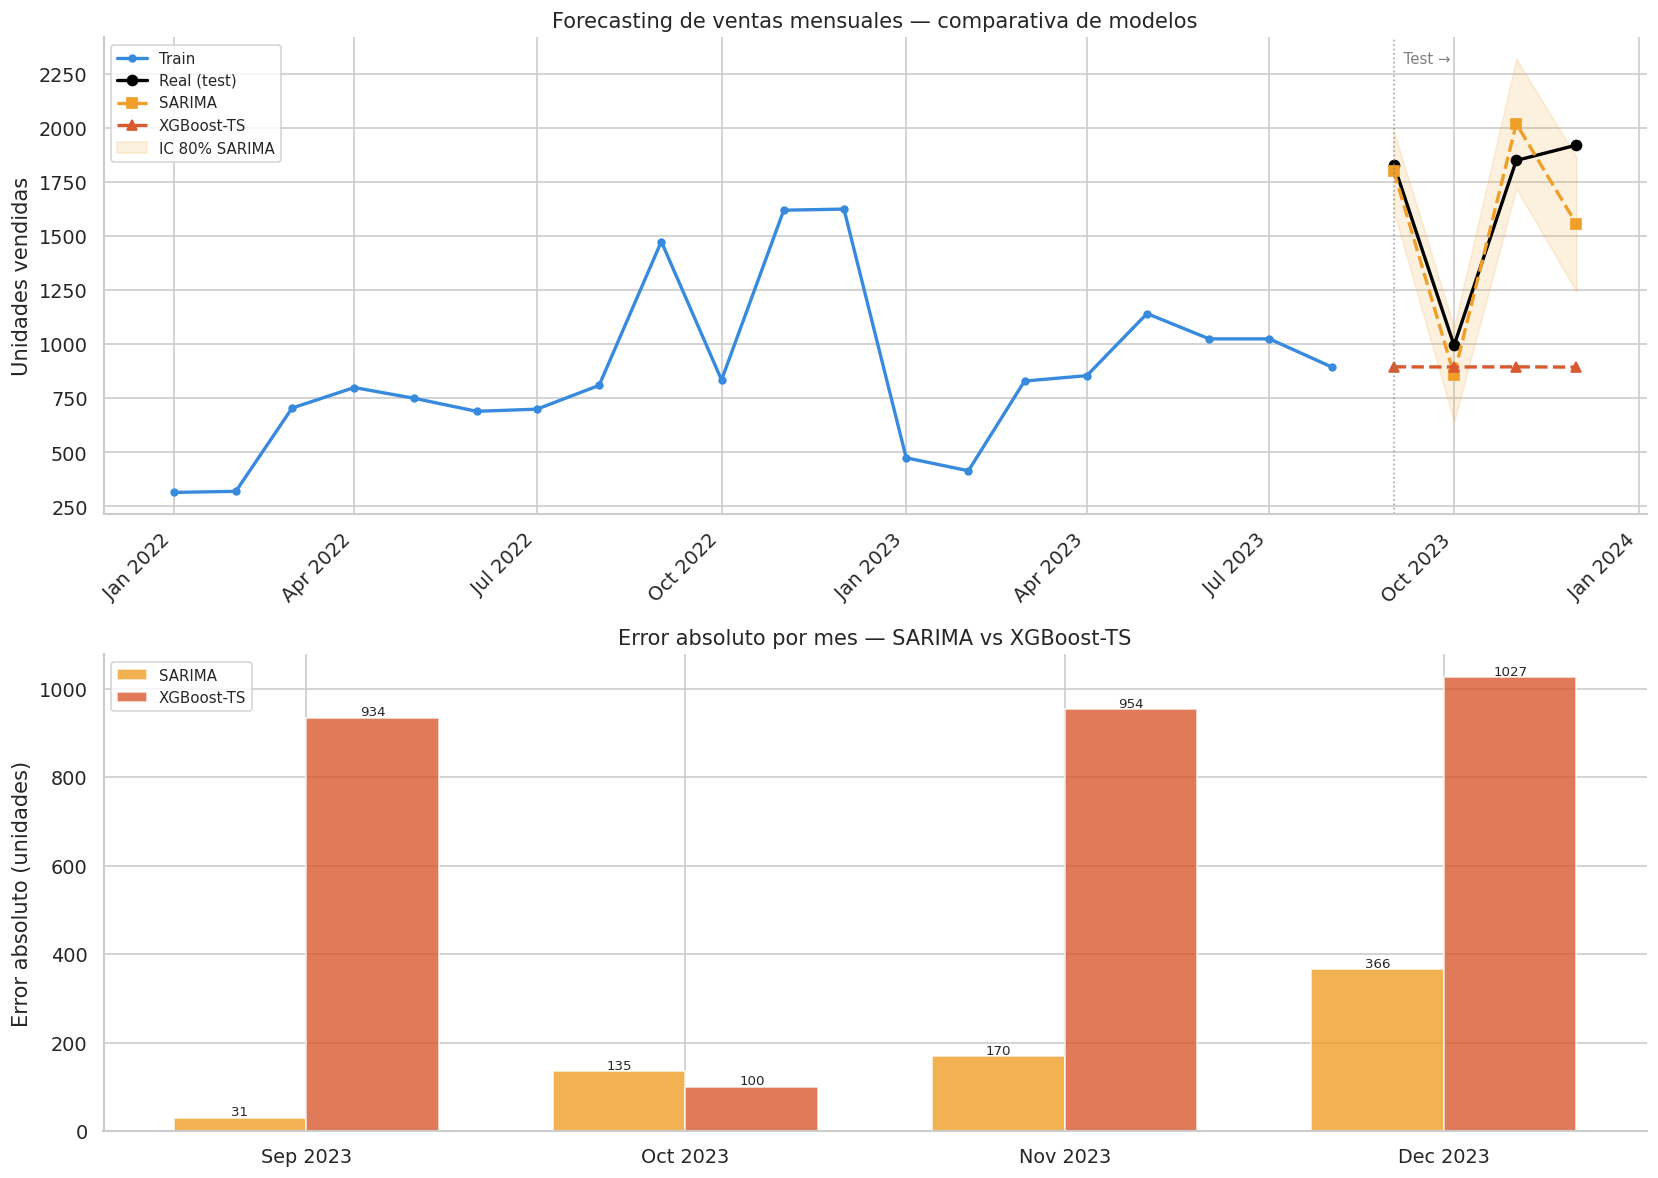

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(ts_train.index, ts_train.values, color=PALETTE[0], lw=2, label='Train', marker='o', markersize=4)
ax.plot(ts_test.index,  ts_test.values,  color='black', lw=2, label='Real (test)', marker='o', markersize=6)
ax.plot(pred_sarima.index, pred_sarima.values,
        color=PALETTE[2], lw=2, ls='--', marker='s', markersize=6, label='SARIMA')
ax.plot(ts_test.index, pred_xgb_ts,
        color=PALETTE[3], lw=2, ls='--', marker='^', markersize=6, label='XGBoost-TS')

forecast_ci = sarima_fit.get_forecast(steps=N_TEST).conf_int(alpha=0.20)
forecast_ci.index = ts_test.index
ax.fill_between(ts_test.index,
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color=PALETTE[2], alpha=0.15, label='IC 80% SARIMA')

ax.axvline(ts_test.index[0], color='gray', lw=1, ls=':', alpha=0.7)
ax.text(ts_test.index[0], ax.get_ylim()[1]*0.95, '  Test →', fontsize=9, color='gray')
ax.set_title('Forecasting de ventas mensuales — comparativa de modelos')
ax.set_ylabel('Unidades vendidas')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax = axes[1]
dates_str = ts_test.index.strftime('%b %Y')
x_pos = np.arange(len(ts_test))
width = 0.35

err_sarima = np.abs(ts_test.values - pred_sarima.values)
err_xgb    = np.abs(y_ts_te.values - pred_xgb_ts)

ax.bar(x_pos - width/2, err_sarima, width, color=PALETTE[2], alpha=0.8, label='SARIMA')
ax.bar(x_pos + width/2, err_xgb,    width, color=PALETTE[3], alpha=0.8, label='XGBoost-TS')

for i, (es, ex) in enumerate(zip(err_sarima, err_xgb)):
    ax.text(i - width/2, es + 5, f'{es:.0f}', ha='center', fontsize=8)
    ax.text(i + width/2, ex + 5, f'{ex:.0f}', ha='center', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(dates_str)
ax.set_ylabel('Error absoluto (unidades)')
ax.set_title('Error absoluto por mes — SARIMA vs XGBoost-TS')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 10.6 Tabla comparativa — Forecasting

In [41]:
df_fc_res = pd.DataFrame([
    {'Modelo': 'SARIMA(1,1,1)(1,1,1,12)', 'MAE': mae_s, 'RMSE': rmse_s, 'MAPE%': mape_s},
    {'Modelo': 'XGBoost-TS',              'MAE': mae_x, 'RMSE': rmse_x, 'MAPE%': mape_x},
]).set_index('Modelo')

print('=== Comparativa de modelos de forecasting (test = últimos 4 meses) ===')
display(df_fc_res.style
    .format({'MAE': '{:,.1f}', 'RMSE': '{:,.1f}', 'MAPE%': '{:.1f}%'})
    .highlight_min(subset=['MAE', 'RMSE', 'MAPE%'], color='#d4edda'))


=== Comparativa de modelos de forecasting (test = últimos 4 meses) ===


,MAE,RMSE,MAPE%
Modelo,,,
"SARIMA(1,1,1)(1,1,1,12)",175.3,213.1,10.9%
XGBoost-TS,753.8,843.7,41.5%


## Interpretabilidad del modelo

*   Se aprecia claramente la dificultad de XGBoost para predecir vs SARIMA
*   XGBoost-TS colapsa a predecir la media (mismo valor los 4 meses).
*   Pocos periodos para XGBoost
*   Con mas periodos seguramente ambos modelos podrian arrojar mejores resultados





---
## 11. Resumen ejecutivo y conclusiones

##  Resumen Ejecutivo — Modelado Car Sales

---

### Modelo de Rentabilidad (target: Price)

**Desempeño de modelos:**

- Regresión Lineal → MAE ~$9,582 | R² ~0.22 → baseline lineal

- Random Forest → MAE ~$9,601 | R² ~0.21 → no supera baseline

- XGBoost → MAE ~$7,487 | R² ~0.50 → mejora significativa  

- HistGradientBoosting → MAE ~$6,650 | R² ~0.57 → mejora adicional

- **LightGBM  → MAE ~$6,542 | R² ~0.58 → mejor modelo**

**Insights clave:**

- Drivers mas importantes: **Model + Company (~45% de la importancia total)**


**Segmentación de mercado:**

- **Premium:** Cadillac, Lexus, Saab → ticket > $34K  

- **Mid-high:** BMW, Mercedes, Buick → ticket ~$28K–34K  

- **Masivo:** Chevrolet, Ford, VW → ticket ~$18K–28K  

**Observaciones:**

- El modelo se comporta muy bien en el rango de 10.000 - 40.000, para valores de vehiculos mayores el modelo no responde tan bien. Se puede deber a la cantidad de datos de vehiculos del sector medio vs vehiculos de alto costo.
- Es posible crear estrategias de marketing correctas para priorizar la venta de ciertos vehiculos frente a otros.
- Podrian ser creadas estrategias de planificacion de compra de aquellos vehiculos que mayor utilidad puedan aportar basado en el costo del fabricante y el precio de venta pudiendo tambien con una optimizacion de costos, mayores valores de utilidad.

---

### Forecasting de Demanda (ventas mensuales)

**Desempeño de modelos:**

- **SARIMA(1,1,1)(1,1,1,12) → MAE ~175 | MAPE ~11% → mejor modelo**

- XGBoost (Time Series) → MAE ~754 | MAPE ~42% → requiere más datos históricos  

**Patrones identificados:**

- Estacionalidad: **Sep, Nov, Dic concentran ~35% de ventas anuales**

- Tendencia: **+24.6% crecimiento YoY (2022 → 2023)**

**Observaciones:**

- Con mas datos historicos el rendimiento podria mejorar ampliamente e incluso se podria evaluar la posibilidad de usar otros modelos (Limite actual n periodos).
- Con un modelo mas robusto podria ser creada una estrategia de planificacion de stock optima en funcion de la demanda potencial y los tiempos de reposicion del stock. El estado actual es un buen orientador pero no permite tener una certeza alta como para usarlo como unica herramienta.